# 01 — Разведочный анализ данных (EDA)

**Цель.** Понять размер и структуру датасета UCI Online News Popularity, выбрать порог для бинаризации `shares`, увидеть основные зависимости признаков заголовка с таргетом. Все графики сохраняются в `report/images/` и затем переиспользуются в отчёте.

**Требования.** `python -m src.data.download` должен быть выполнен (или `make data`).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import (
    CSV_TITLE_FEATURES,
    DATA_CHANNEL_COLS,
    RAW_CSV_PATH,
    REPORT_IMAGES_DIR,
    TARGET_COL,
    VIRAL_TOP_QUANTILE,
    WEEKDAY_COLS,
    ensure_directories,
)
from src.utils.seed import set_global_seed

set_global_seed()
ensure_directories()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv(RAW_CSV_PATH)
df.columns = [c.strip() for c in df.columns]
print(f"Размерность датасета: {df.shape}")
print(f"Колонок: {df.shape[1]}, строк: {df.shape[0]}")
df.head(3)

Размерность датасета: (39644, 61)
Колонок: 61, строк: 39644


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


In [3]:
print('Пропуски по колонкам (только ненулевые):')
missing = df.isna().sum()
print(missing[missing > 0])
print()
print(f'Duplicate URLs: {df.duplicated(subset=["url"]).sum()}')

Пропуски по колонкам (только ненулевые):
Series([], dtype: int64)

Duplicate URLs: 0


In [4]:
anomalies = df[df["n_unique_tokens"] > 1.0]
print(f'Documented UCI anomaly (n_unique_tokens > 1): {len(anomalies)} rows')
anomalies[["url", "n_unique_tokens", "n_non_stop_words", TARGET_COL]].head()

Documented UCI anomaly (n_unique_tokens > 1): 1 rows


,url,n_unique_tokens,n_non_stop_words,shares
31037,http://mashable.com/2014/08/18/ukraine-civilia...,701.0,1042.0,5900


In [5]:
df_clean = df[df["n_unique_tokens"] <= 1.0].reset_index(drop=True)
shares = df_clean[TARGET_COL]
median = float(shares.median())
viral_threshold = float(shares.quantile(VIRAL_TOP_QUANTILE))
print(f'shares: min={shares.min()}  median={median:.0f}  mean={shares.mean():.0f}  max={shares.max()}')
print(f'Top-{int(VIRAL_TOP_QUANTILE*100)}% threshold: {viral_threshold:.0f}')
print(f'Balance @ median: {(shares >= median).mean():.3f}')
print(f'Balance @ top-20%: {(shares >= viral_threshold).mean():.3f}')

shares: min=1  median=1400  mean=3395  max=843300
Top-80% threshold: 3400
Balance @ median: 0.534
Balance @ top-20%: 0.204


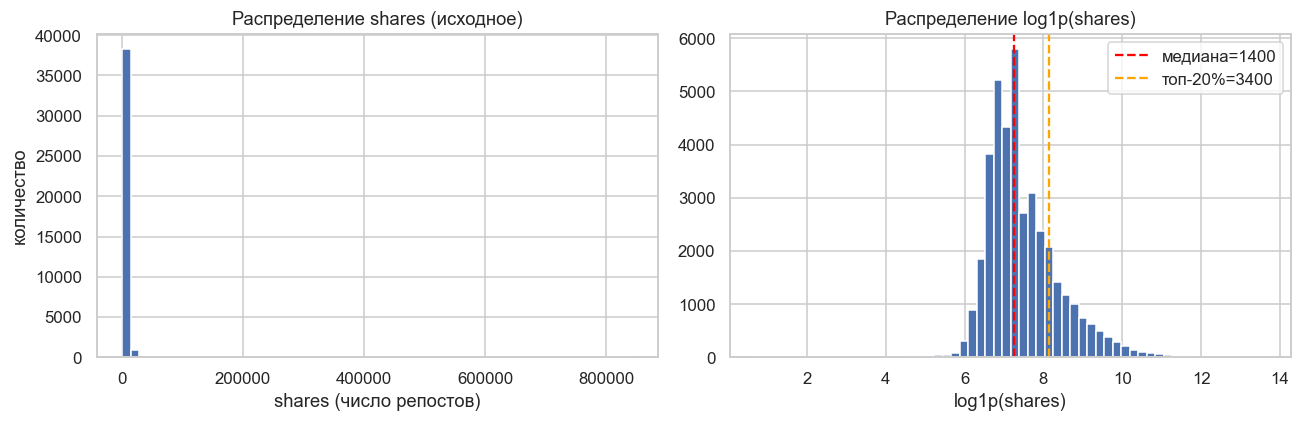

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(shares, bins=60)
axes[0].set_title('Распределение shares (исходное)')
axes[0].set_xlabel('shares (число репостов)'); axes[0].set_ylabel('количество')
axes[1].hist(np.log1p(shares), bins=60)
axes[1].axvline(np.log1p(median), color='red', linestyle='--', label=f'медиана={median:.0f}')
axes[1].axvline(np.log1p(viral_threshold), color='orange', linestyle='--', label=f'топ-20%={viral_threshold:.0f}')
axes[1].set_title('Распределение log1p(shares)'); axes[1].set_xlabel('log1p(shares)'); axes[1].legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '01_shares_distribution.png', bbox_inches='tight')
plt.show()

         channel  count  median_shares
3         socmed   2323         2100.0
6          other   6134         1900.0
0      lifestyle   2099         1700.0
4           tech   7346         1700.0
2            bus   6258         1400.0
1  entertainment   7056         1200.0
5          world   8427         1100.0


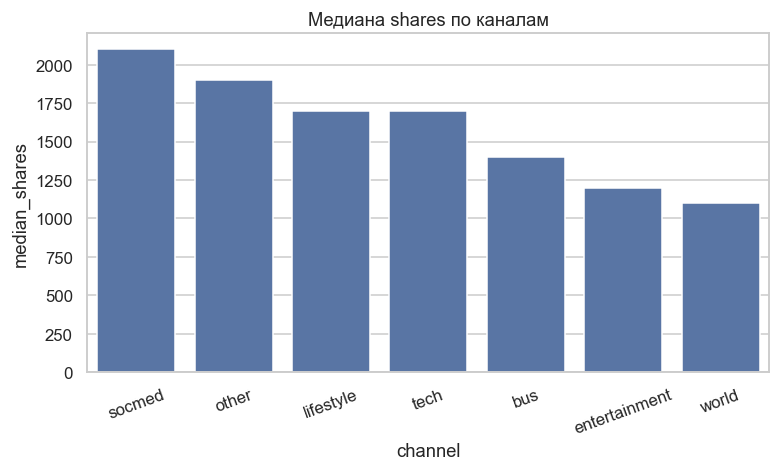

In [7]:
channel_map = {c: c.replace('data_channel_is_', '') for c in DATA_CHANNEL_COLS if c in df_clean.columns}
rows = []
for c, name in channel_map.items():
    subset = df_clean[df_clean[c] == 1]
    if len(subset):
        rows.append({'channel': name, 'count': len(subset), 'median_shares': subset[TARGET_COL].median()})
rows.append({'channel': 'other', 'count': int((df_clean[list(channel_map.keys())].sum(axis=1) == 0).sum()),
             'median_shares': float(df_clean[df_clean[list(channel_map.keys())].sum(axis=1) == 0][TARGET_COL].median())})
channels = pd.DataFrame(rows).sort_values('median_shares', ascending=False)
print(channels)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x='channel', y='median_shares', data=channels, ax=ax)
ax.set_title('Медиана shares по каналам'); ax.tick_params(axis='x', rotation=20)
plt.savefig(REPORT_IMAGES_DIR / '01_shares_by_channel.png', bbox_inches='tight')
plt.show()

In [8]:
weekdays = [c for c in WEEKDAY_COLS if c.startswith('weekday_is_') and c in df_clean.columns]
wk_rows = []
for c in weekdays:
    subset = df_clean[df_clean[c] == 1]
    wk_rows.append({'weekday': c.replace('weekday_is_', ''), 'count': len(subset),
                    'median_shares': subset[TARGET_COL].median()})
wk = pd.DataFrame(wk_rows)
wk

,weekday,count,median_shares
0,monday,6661,1400.0
1,tuesday,7389,1300.0
2,wednesday,7435,1300.0
3,thursday,7267,1400.0
4,friday,5701,1500.0
5,saturday,2453,2000.0
6,sunday,2737,1900.0


Pearson correlation of CSV title features with log1p(shares):
                              corr_log_shares
abs_title_sentiment_polarity         0.059215
title_subjectivity                   0.052742
title_sentiment_polarity             0.051048
n_tokens_title                      -0.019027
abs_title_subjectivity               0.000821


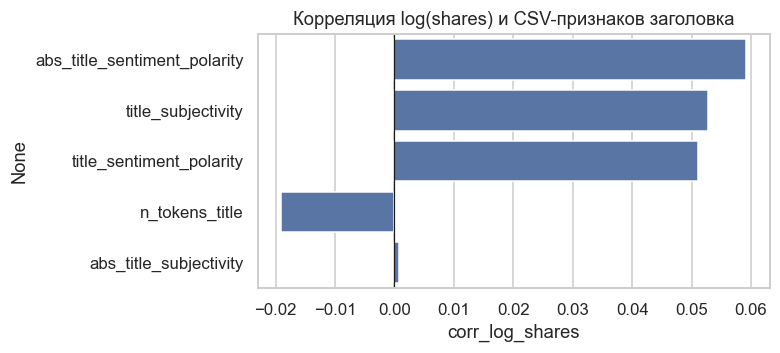

In [9]:
log_shares = np.log1p(df_clean[TARGET_COL])
cor = pd.DataFrame({c: [df_clean[c].corr(log_shares)] for c in CSV_TITLE_FEATURES if c in df_clean.columns}).T
cor.columns = ['corr_log_shares']
cor = cor.sort_values('corr_log_shares', key=np.abs, ascending=False)
print('Pearson correlation of CSV title features with log1p(shares):')
print(cor)
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=cor['corr_log_shares'], y=cor.index, ax=ax, orient='h')
ax.set_title('Корреляция log(shares) и CSV-признаков заголовка'); ax.axvline(0, color='k', linewidth=0.8)
plt.savefig(REPORT_IMAGES_DIR / '01_csv_title_correlations.png', bbox_inches='tight')
plt.show()

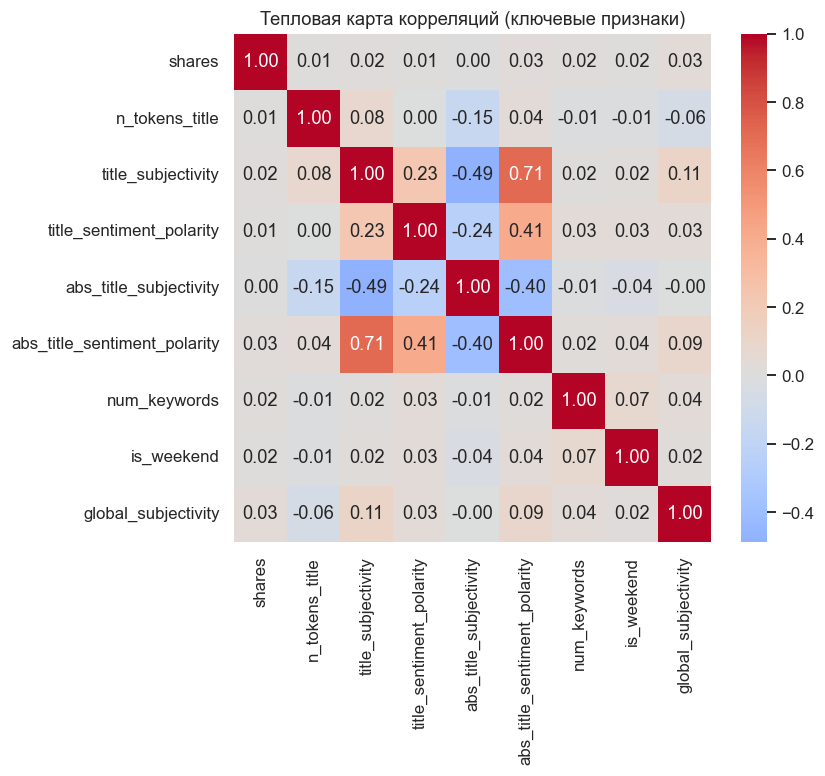

In [10]:
cols_for_heatmap = [TARGET_COL, 'n_tokens_title', 'title_subjectivity', 'title_sentiment_polarity',
                    'abs_title_subjectivity', 'abs_title_sentiment_polarity', 'num_keywords',
                    'is_weekend', 'global_subjectivity']
cols_for_heatmap = [c for c in cols_for_heatmap if c in df_clean.columns]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_clean[cols_for_heatmap].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Тепловая карта корреляций (ключевые признаки)')
plt.savefig(REPORT_IMAGES_DIR / '01_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Выводы (01_eda)

* Датасет полный (пропусков нет), но содержит ~2% документированных аномалий (`n_unique_tokens == 701`). Их удаляем.
* Распределение `shares` сильно правосторонне скошено — работаем через `log1p` для визуализаций и через бинаризацию для моделирования.
* Медиана ≈ 1 400, top-20% ≈ 2 500+ — используем медиану как главный порог и оставляем top-20% для ablation.
* Готовые CSV title-фичи коррелируют с `log shares` слабо (\|r\| < 0.08), поэтому feature engineering по тексту заголовка критичен.